# Spyglass Tutorial: multi-camera 3D pose and social contacts (Olveczky Lab, Klibaite et al. 2025)

This notebook reads the Olveczky Lab social behavior data (the dataset published as
[DANDI:001936](https://dandiarchive.org/dandiset/001936)) **from a Spyglass database** instead of
from the NWB files. It mirrors the two NWB tutorials in
`src/olveczky_lab_to_nwb/klibaite_2025_rat/notebooks/`:

- **Part 1** follows `dandi_001936_tutorial.ipynb`: one rat's session (videos, 3D pose, skeleton,
  camera calibration, skin contacts).
- **Part 2** follows `two_subject_tutorial.ipynb`: both rats of a session together.

Two rats share an arena recorded by **6 calibrated cameras**. **sDANNCE** tracks 23 3D keypoints
per rat, and pairwise **skin contacts** are derived from the rats' 3D body meshes. Each NWB file
holds one rat's perspective of a session.

## How the NWB file maps onto Spyglass

The standard NWB files (ndx-pose 0.4.0, NWB core `EventsTable`) were inserted with Spyglass's own
`insert_sessions()`, unmodified. Multi-camera pose is modelled the way Spyglass models single-camera
DeepLabCut pose (`DLCPoseEstimation` is tied to one `VideoFile`), extended to several calibrated
cameras:

| NWB object | Spyglass table |
|---|---|
| `CalibratedCamera` devices | `CameraDevice` (camera) + `CameraCalibration` (per-session geometry) |
| `ImageSeries` (external `.mp4`), one per camera | `VideoFile`, under a `TaskEpoch` |
| `MultiCameraPoseEstimation` | `ImportedMultiCameraPose` |
| its `PoseEstimationSeries` (one per keypoint) | `ImportedMultiCameraPose.BodyPart` |
| its per-camera `PoseEstimation` (camera + video links) | `ImportedMultiCameraPose.Camera` (`-> VideoFile`, `-> CameraCalibration`) |
| `EventsTable` | `ImportedEvents` |

The files carry no task metadata, so Spyglass creates a **default epoch** (`01_default`) spanning
the videos. The arrays stay in the NWB files; the tables hold references, and fetch methods
return the data.

## Setup

Run inside the `spyglass-olveczky` environment (see `spyglass/bootstrap_wsl.sh`), with the
database from `spyglass/docker-compose.yml` up and a `spyglass/dj_local_conf.json` pointing at it.

In [1]:
from pathlib import Path, PureWindowsPath

import datajoint as dj

# The connection settings must be loaded before Spyglass is imported.
dj.config.load(str(Path.cwd().parent / "dj_local_conf.json"))
dj.conn(use_tls=False)

import cv2
import matplotlib.pyplot as plt
import numpy as np

import spyglass.common as sgc
from spyglass.common.common_usage import InsertError
from spyglass.position.v1.imported_multicam_pose import CameraCalibration, ImportedMultiCameraPose
from spyglass.utils.nwb_helper_fn import get_image_series_timestamps

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Rat 1 = blue, Rat 2 = red -- used consistently in Part 2.
RAT_COLORS = {1: "blue", 2: "red"}

[2026-10-05 12:44:27,097][INFO]: DataJoint is configured from /mnt/c/Users/algab/CatalystNeuro/olveczky-lab-to-nwb/spyglass/dj_local_conf.json


[2026-10-05 12:44:27,107][INFO]: DataJoint 0.14.9 connected to root@127.0.0.1:3309


### Helpers

The videos are referenced by the path written at conversion time (here a Windows path), so map it
to this machine before opening it. Pose columns are named after the NWB `PoseEstimationSeries`,
which are named after the skeleton nodes.

In [2]:
def local_video_path(path):
    """Map a Windows path (e.g. F:\\...) to its WSL mount (/mnt/f/...) when running on Linux."""
    windows_path = PureWindowsPath(path)
    if windows_path.drive and Path("/mnt").exists():
        return str(Path("/mnt", windows_path.drive[0].lower(), *windows_path.parts[1:]))
    return str(path)


def series_name(node):
    return f"PoseEstimationSeries{node}"


def read_frame(video_path, frame_idx):
    """One RGB frame of a video, or None if it cannot be read."""
    cap = cv2.VideoCapture(local_video_path(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    success, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if success else None


def project_points(points_3d, calibration):
    """Project (n, 3) world-space points (mm) into a camera's 2D pixel coordinates.

    `calibration` is a dict from `CameraCalibration.fetch_calibration()`. DANNCE matrices are stored
    in MATLAB's row-vector convention (``x_cam = x_world @ r + t``, ``x_pixel ~ x_cam @ K``), the
    transpose of what `cv2.projectPoints` expects -- hence transposing the rotation and intrinsics.
    """
    rotation_vector, _ = cv2.Rodrigues(calibration["rotation_matrix"].T)
    points_2d, _ = cv2.projectPoints(
        np.ascontiguousarray(points_3d, dtype=float),
        rotation_vector,
        np.ravel(calibration["translation_vector"]).astype(float),
        calibration["intrinsic_matrix"].T.astype(float),
        calibration["distortion_coefficients"],
    )
    return points_2d.reshape(-1, 2)

## What is in the database

Every inserted session, with the number of entries each table holds for it. Each NWB file is one
Spyglass `Session` (one rat); the two rats of a recording share its `session_id`.

In [3]:
sessions = (sgc.Session * sgc.Subject).fetch(
    "nwb_file_name", "subject_id", "session_id", "genotype", "sex", as_dict=True, order_by="nwb_file_name"
)
counted_tables = {
    "VideoFile": sgc.VideoFile,
    "CameraCalibration": CameraCalibration,
    "Pose": ImportedMultiCameraPose,
    "BodyPart": ImportedMultiCameraPose.BodyPart,
    "Camera": ImportedMultiCameraPose.Camera,
    "Events": sgc.ImportedEvents,
    "InsertError": InsertError,
}
for session in sessions:
    key = {"nwb_file_name": session["nwb_file_name"]}
    session["counts"] = {name: len(table & key) for name, table in counted_tables.items()}
    print(f"{session['subject_id']:<11} {session['session_id']:<30} {session['counts']}")

# Completeness: every session is fully ingested, with no errors.
assert len(sessions) == 4
for session in sessions:
    assert session["counts"] == {
        "VideoFile": 6, "CameraCalibration": 6, "Pose": 1, "BodyPart": 23, "Camera": 6, "Events": 1, "InsertError": 0
    }, session

ARID1B-M1   day-1-social-M1-M2-20221017    {'VideoFile': 6, 'CameraCalibration': 6, 'Pose': 1, 'BodyPart': 23, 'Camera': 6, 'Events': 1, 'InsertError': 0}
ARID1B-M2   day-1-social-M1-M2-20221017    {'VideoFile': 6, 'CameraCalibration': 6, 'Pose': 1, 'BodyPart': 23, 'Camera': 6, 'Events': 1, 'InsertError': 0}
ARID1B-M3   day-1-social-M3-M4-20221017    {'VideoFile': 6, 'CameraCalibration': 6, 'Pose': 1, 'BodyPart': 23, 'Camera': 6, 'Events': 1, 'InsertError': 0}
ARID1B-M4   day-1-social-M3-M4-20221017    {'VideoFile': 6, 'CameraCalibration': 6, 'Pose': 1, 'BodyPart': 23, 'Camera': 6, 'Events': 1, 'InsertError': 0}


---
# Part 1: one rat's session

Mirrors `dandi_001936_tutorial.ipynb`. Pick a rat and a session; everything below is restricted
to that one Spyglass session.

In [4]:
subject_id = "ARID1B-M1"
session_id = "day-1-social-M1-M2-20221017"

session_key = (sgc.Session & {"subject_id": subject_id, "session_id": session_id}).fetch1("KEY")
pose = ImportedMultiCameraPose & session_key
session_key

{'nwb_file_name': 'sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb'}

## 1. Session and subject

In [5]:
session = (sgc.Session & session_key).fetch1()
print("Session description:", session["session_description"])
print("Session start time: ", session["session_start_time"])
print()

subject = (sgc.Subject & {"subject_id": session["subject_id"]}).fetch1()
for field in ("subject_id", "species", "genotype", "sex", "description"):
    print(f"{field + ':':<13}", subject[field])

Session description: Social behavior experiment in the Olveczky Lab. Two rats of defined genotypes were placed together in an arena and their behavior was recorded with a six-camera system. 3D pose estimation was performed using sDANNCE. Cohort group: ARID1B, encounter round: SOC1, session: M1 (rat1) vs M2 (rat2).
Session start time:  2022-10-17 00:00:00

subject_id:   ARID1B-M1
species:      Rattus norvegicus
genotype:     KO wt
sex:          M
description:  Rat M1 from cohort ARID1B. Marking: LB. Cage: 2. Mother: LEF0537. Supplier: Medical College of Wisconsin. RRID: RGD_14394518


## 2. Epoch, cameras and videos

The file has no task metadata, so Spyglass created a default epoch over the videos' time span, and
attached all six cameras to it.

In [6]:
(sgc.TaskEpoch & session_key).fetch(
    "epoch", "task_name", "interval_list_name", "camera_names", as_dict=True
)

[{'epoch': 1,
  'task_name': 'default',
  'interval_list_name': '01_default',
  'camera_names': [{'camera_name': 'Camera1'},
   {'camera_name': 'Camera2'},
   {'camera_name': 'Camera3'},
   {'camera_name': 'Camera4'},
   {'camera_name': 'Camera5'},
   {'camera_name': 'Camera6'}]}]

In [7]:
for name, valid_times in zip(*(sgc.IntervalList & session_key).fetch("interval_list_name", "valid_times")):
    print(f"{name}: {np.round(valid_times, 3).tolist()}")

01_default: [[0.0, 1801.366]]
pose_PoseEstimationSDANNCE_valid_intervals: [[-0.0, 1801.356]]


In [8]:
sgc.CameraDevice * (CameraCalibration & session_key)

camera_name,nwb_file_name name of the NWB file,meters_per_pixel height / width of pixel in meters,manufacturer,model,lens,camera_id,"calibrated_camera_object_id NWB object id, for fetch_nwb()"
Camera1,sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,0.0,basler,a2A1920-160ucBAS,,1,45ba4285-b09d-4a52-83b6-5a91d60ac34d
Camera2,sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,0.0,basler,a2A1920-160ucBAS,,2,bbbe5a73-0331-461f-b0e3-406338d2380d
Camera3,sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,0.0,basler,a2A1920-160ucBAS,,3,891e9099-bc96-4a43-a881-03ebde845e97
Camera4,sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,0.0,basler,a2A1920-160ucBAS,,4,753ba930-9932-4ac8-a763-208c1e14c4b6
Camera5,sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,0.0,basler,a2A1920-160ucBAS,,5,0b0a29c8-8027-4a20-8270-7d2a76c36b8b
Camera6,sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,0.0,basler,a2A1920-160ucBAS,,6,723dd117-36c5-43ed-9c29-f1be94ac3bb7


### 2a. Video acquisition (6 cameras)

Each `VideoFile` references an `ImageSeries` that points to an external `.mp4`. Its frame times
come from the camera's frame-time log; `fetch_nwb()` returns the `ImageSeries` itself.

In [9]:
for video in (sgc.VideoFile & session_key).fetch_nwb():
    timestamps = get_image_series_timestamps(video["video_file"])
    print(f"{video['camera_name']}: {len(timestamps)} frames, {1 / np.median(np.diff(timestamps)):.2f} Hz")

Camera1: 90000 frames, 49.96 Hz
Camera2: 90000 frames, 49.96 Hz
Camera3: 90000 frames, 49.96 Hz
Camera4: 90000 frames, 49.96 Hz
Camera5: 90000 frames, 49.96 Hz
Camera6: 90000 frames, 49.96 Hz


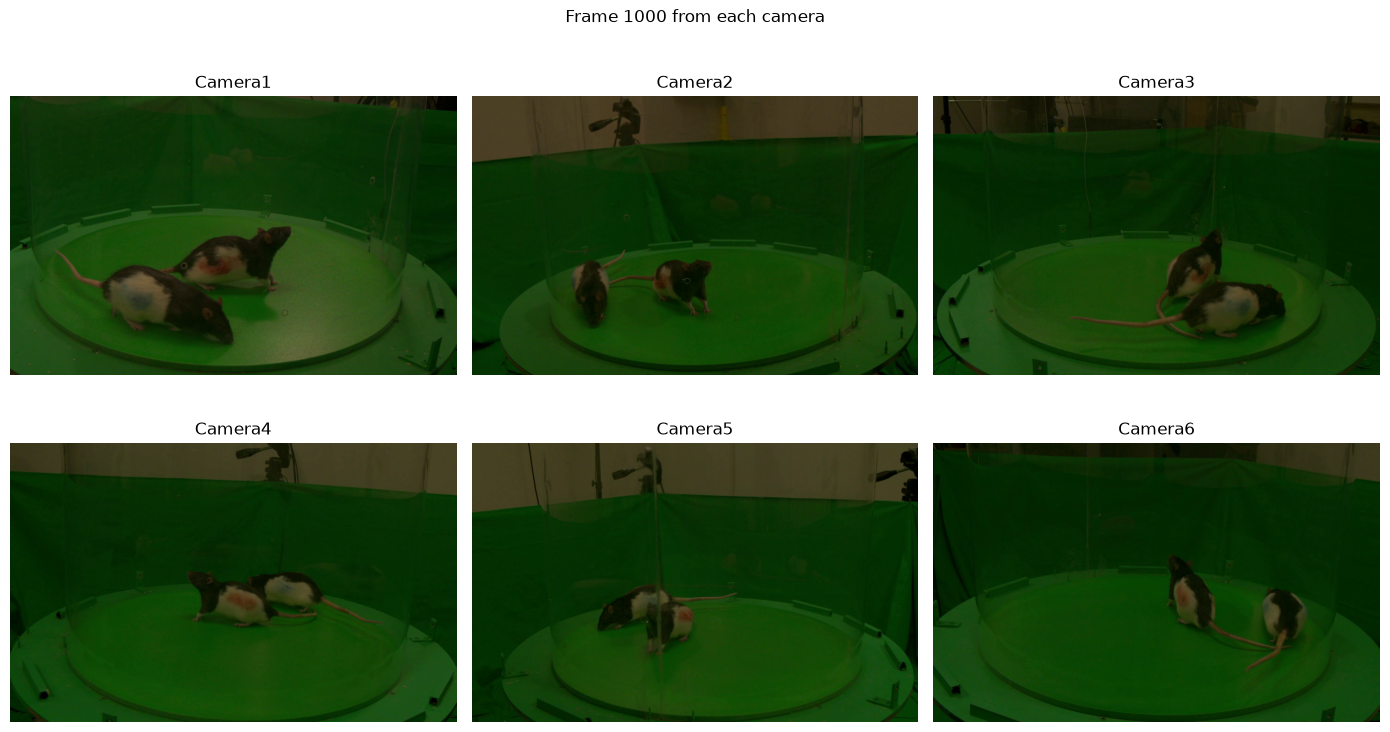

In [10]:
video_paths = pose.fetch_video_paths()  # camera name -> path, through ImportedMultiCameraPose.Camera

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, camera_name in zip(axes.flat, sorted(video_paths)):
    frame = read_frame(video_paths[camera_name], 1000)  # an arbitrary frame partway through
    if frame is not None:
        ax.imshow(frame)
    ax.set_title(camera_name)
    ax.axis("off")
fig.suptitle("Frame 1000 from each camera")
fig.tight_layout()

## 3. 3D pose estimation (sDANNCE)

`ImportedMultiCameraPose` holds one entry per pose container, with the software that produced it,
and one `BodyPart` per keypoint. `fetch_pose_dataframe()` returns every keypoint's (x, y, z) in
millimeters and its confidence, indexed by time.

In [11]:
pose.fetch("pose_estimation_name", "source_software", "scorer", "description", "interval_list_name", as_dict=True)

[{'pose_estimation_name': 'PoseEstimationSDANNCE',
  'interval_list_name': 'pose_PoseEstimationSDANNCE_valid_intervals',
  'source_software': 'sDANNCE',
  'scorer': 'sDANNCE',
  'description': '3D keypoint coordinates estimated using sDANNCE (social DANNCE).'}]

In [12]:
pose_df = pose.fetch_pose_dataframe()
keypoints = (ImportedMultiCameraPose.BodyPart & session_key).fetch("part_name")
print(f"{len(keypoints)} keypoints, {len(pose_df)} samples")
pose_df.head()

23 keypoints, 90000 samples


PoseEstimationSeriesAnkleLeft                                   \
                                     x          y          z likelihood   
time                                                                      
0.000000                    115.372047  -4.829000  12.222997  26.350128   
0.020015                    123.500839 -12.879790  10.406721  26.757193   
0.040031                    128.267181 -18.447285   8.628425  26.425804   
0.060046                    135.026611 -24.887590   6.997382  26.621202   
0.080061                    139.204575 -26.173594   6.435434  26.576303   

         PoseEstimationSeriesAnkleRight                                  \
                                      x          y         z likelihood   
time                                                                      
0.000000                     115.124893 -58.855625  6.134002  26.350128   
0.020015                     115.707138 -59.730564  6.264191  26.757193   
0.040031                     115.791679 -60.145233  6.810301  26.425804   
0.060046                     115.132942 -60.965824  6.811278  26.621202   
0.080061                     115.013062 -60.785534  6.830951  26.576303   

         PoseEstimationSeriesEarLeft              ...  \
                                   x           y  ...   
time                                              ...   
0.000000                  200.875763 -144.051392  ...   
0.020015                  200.574478 -146.971863  ...   
0.040031                  200.620285 -148.409210  ...   
0.060046                  200.446884 -149.532715  ...   
0.080061                  200.498123 -150.355530  ...   

         PoseEstimationSeriesTailBase             \
                                    z likelihood   
time                                               
0.000000                    24.899073  26.350128   
0.020015                    25.015823  26.757193   
0.040031                    24.278759  26.425804   
0.060046                    23.487274  26.621202   
0.080061                    22.923519  26.576303   

         PoseEstimationSeriesWristLeft                                   \
                                     x           y         z likelihood   
time                                                                      
0.000000                    201.196335 -106.503021  8.393961  26.350128   
0.020015                    201.081635 -106.493645  8.398374  26.757193   
0.040031                    201.577087 -106.848534  8.689681  26.425804   
0.060046                    201.528961 -107.074944  8.809628  26.621202   
0.080061                    201.458618 -107.663002  9.107328  26.576303   

         PoseEstimationSeriesWristRight                                    
                                      x           y          z likelihood  
time                                                                       
0.000000                     166.106644 -122.534668  12.695019  26.350128  
0.020015                     166.017670 -123.028130  12.684708  26.757193  
0.040031                     166.877838 -124.118385  13.041233  26.425804  
0.060046                     166.801361 -125.048996  12.999137  26.621202  
0.080061                     166.928345 -126.369286  13.011406  26.576303  

[5 rows x 92 columns]

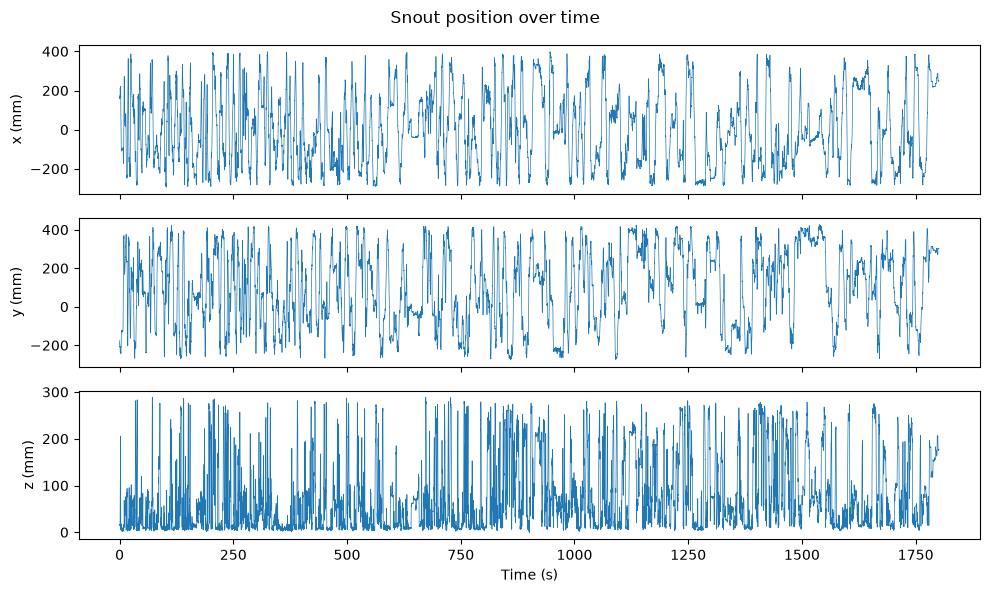

In [13]:
# XYZ trajectory of the snout over the whole session
snout_xyz = pose_df[series_name("Snout")][["x", "y", "z"]].to_numpy()
t = pose_df.index.to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, dim, label in zip(axes, range(3), ["x", "y", "z"]):
    ax.plot(t, snout_xyz[:, dim], linewidth=0.5)
    ax.set_ylabel(f"{label} (mm)")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Snout position over time")
fig.tight_layout()

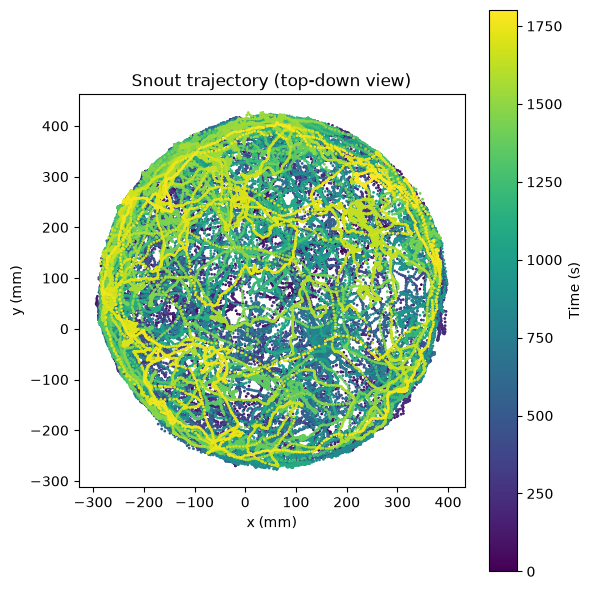

In [14]:
# Top-down (x, y) trajectory, colored by time
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(snout_xyz[:, 0], snout_xyz[:, 1], c=t, cmap="viridis", s=1)
fig.colorbar(sc, ax=ax, label="Time (s)")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_aspect("equal")
ax.set_title("Snout trajectory (top-down view)")
fig.tight_layout()

## 4. Skeleton definition + a single pose frame

`fetch_skeleton()` returns the keypoint graph: node names and edges as name pairs.

In [15]:
skeleton = pose.fetch_skeleton()
nodes = skeleton["nodes"]
edges = [(nodes.index(a), nodes.index(b)) for a, b in skeleton["edges"]]
print(f"{len(nodes)} nodes, {len(edges)} edges")
print(nodes)

23 nodes, 23 edges
['Snout', 'EarLeft', 'EarRight', 'SpineFront', 'SpineMiddle', 'SpineLow', 'TailBase', 'ShoulderLeft', 'ElbowLeft', 'WristLeft', 'HandLeft', 'ShoulderRight', 'ElbowRight', 'WristRight', 'HandRight', 'HipLeft', 'KneeLeft', 'AnkleLeft', 'FootLeft', 'HipRight', 'KneeRight', 'AnkleRight', 'FootRight']


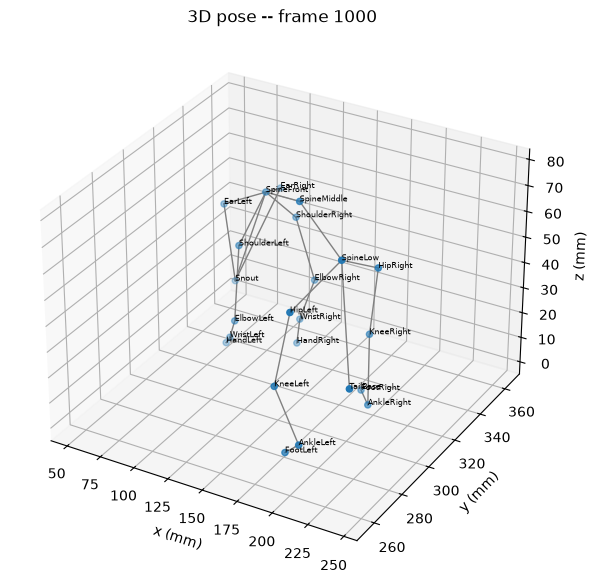

In [16]:
frame_idx = 1000  # pose samples map one-to-one onto video frames in this dataset

# (x, y, z) of every keypoint at this frame, in `nodes` order
coords = np.array([pose_df[series_name(node)][["x", "y", "z"]].iloc[frame_idx].to_numpy() for node in nodes])

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], color="tab:blue", s=20)
for node_i, node_j in edges:
    xs, ys, zs = coords[[node_i, node_j]].T
    ax.plot(xs, ys, zs, color="gray", linewidth=1)
for node_name, (x, y, z) in zip(nodes, coords):
    ax.text(x, y, z, node_name, fontsize=6)

ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("z (mm)")
ax.set_title(f"3D pose -- frame {frame_idx}")
fig.tight_layout()

## 5. Pose keypoints overlaid on a video frame

Each `ImportedMultiCameraPose.Camera` entry ties the pose to one camera's `VideoFile` and to that
camera's `CameraCalibration` for this session. `fetch_calibrations()` returns the intrinsic,
rotation, translation and distortion arrays per camera, so the 3D keypoints (millimeters, world
coordinates) can be projected into any camera's pixels.

In [17]:
ImportedMultiCameraPose.Camera & session_key

nwb_file_name name of the NWB file,pose_estimation_name name of the container in the NWB file,epoch the session epoch for this task and apparatus(1 based),video_file_num,camera_name,camera_pose_object_id the per-camera PoseEstimation
sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,PoseEstimationSDANNCE,1,1,Camera1,bb90a724-1dca-470f-81f5-5406d395a7df
sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,PoseEstimationSDANNCE,1,2,Camera2,5adca62d-a5e5-44fe-865d-2846500c1a3f
sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,PoseEstimationSDANNCE,1,3,Camera3,7d270e2f-99ec-4272-97b8-b9a2c8934c25
sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,PoseEstimationSDANNCE,1,4,Camera4,ed2a8bbd-da1d-4748-8a27-5fea9b678ab4
sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,PoseEstimationSDANNCE,1,5,Camera5,93d8cae5-ee93-40b2-8380-92995380f86c
sub-ARID1B-M1_ses-day-1-social-M1-M2-20221017_.nwb,PoseEstimationSDANNCE,1,6,Camera6,2c2724f6-3a46-4c3f-bbbf-499b8fe0b30a


In [18]:
calibrations = pose.fetch_calibrations()
camera_to_display = "Camera1"
{name: np.shape(value) for name, value in calibrations[camera_to_display].items()}

{'intrinsic_matrix': (3, 3),
 'rotation_matrix': (3, 3),
 'translation_vector': (3,),
 'distortion_coefficients': (4,)}

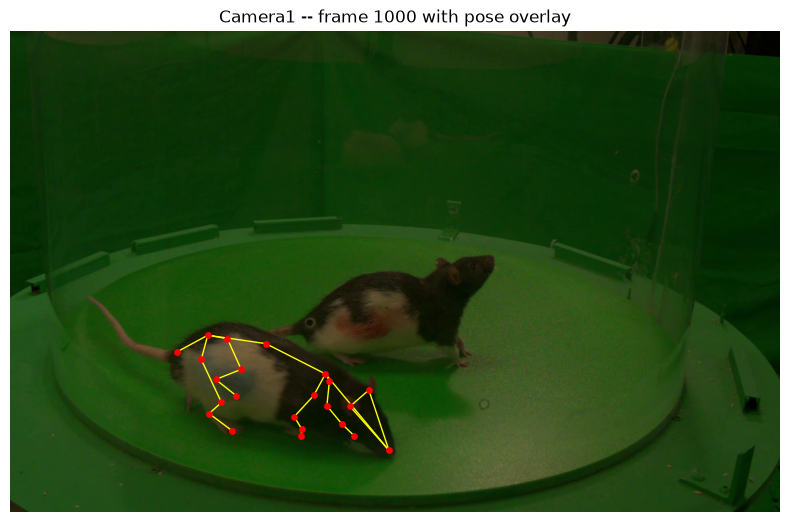

In [19]:
frame = read_frame(video_paths[camera_to_display], frame_idx)  # frame_idx from section 4

if frame is not None:
    points_2d = project_points(coords, calibrations[camera_to_display])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(frame)
    for node_i, node_j in edges:
        xs, ys = points_2d[[node_i, node_j]].T
        ax.plot(xs, ys, color="yellow", linewidth=1)
    ax.scatter(points_2d[:, 0], points_2d[:, 1], color="red", s=15, zorder=3)
    ax.set_title(f"{camera_to_display} -- frame {frame_idx} with pose overlay")
    ax.axis("off")
    fig.tight_layout()
else:
    print(f"Could not read frame {frame_idx} from {camera_to_display} ({video_paths[camera_to_display]})")

## 6. Body-contact events between the two rats

`ImportedEvents` references the NWB `EventsTable`; `fetch1_dataframe()` returns its rows, one per
contact, labeled by the body parts involved.

In [20]:
events = sgc.ImportedEvents & session_key
print(events.fetch1("events_name", "n_events"))
contacts_df = events.fetch1_dataframe()
contacts_df.head()

('SkinContacts', 5112209)


,timestamp,event_type,frame_index,rat1_vertex,rat2_vertex
id,,,,,
0,0.0,right finger x right foot,0,1610,185
1,0.0,right finger x right foot,0,1613,185
2,0.0,right finger x right foot,0,1614,189
3,0.0,right finger x right foot,0,1615,185
4,0.0,right finger x right foot,0,1625,189


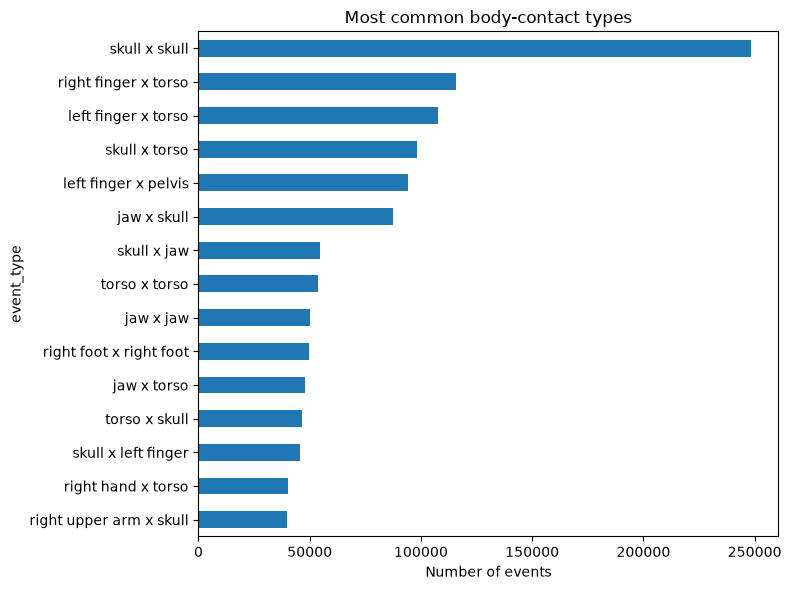

In [21]:
top_contacts = contacts_df["event_type"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_contacts.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Number of events")
ax.set_title("Most common body-contact types")
fig.tight_layout()

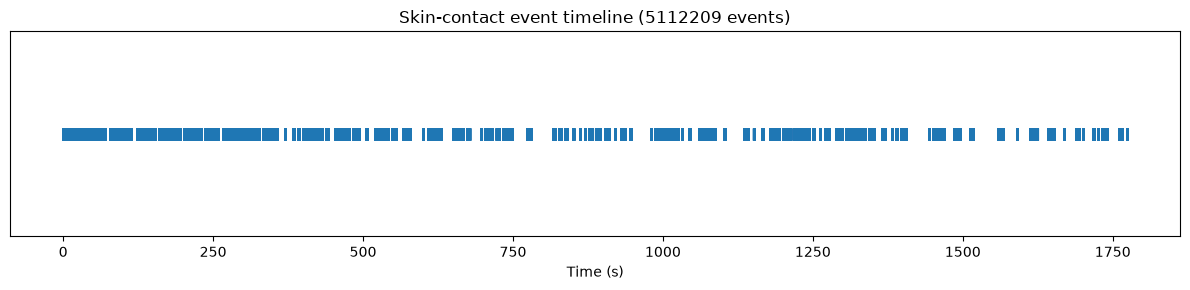

In [22]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(contacts_df["timestamp"], np.zeros(len(contacts_df)), "|", markersize=8, alpha=0.3)
ax.set_xlabel("Time (s)")
ax.set_yticks([])
ax.set_title(f"Skin-contact event timeline ({len(contacts_df)} events)")
fig.tight_layout()

---
# Part 2: both rats of a session

Mirrors `two_subject_tutorial.ipynb`. Each rat's NWB file is its own Spyglass `Session`, and both
share the recording's `session_id`, so restricting `Session` by `session_id` returns the pair.

In [23]:
session_id = "day-1-social-M1-M2-20221017"  # shared by both rats
subject_id_rat1, subject_id_rat2 = "ARID1B-M1", "ARID1B-M2"

pair_keys = {
    rat_idx: (sgc.Session & {"session_id": session_id, "subject_id": subject}).fetch1("KEY")
    for rat_idx, subject in [(1, subject_id_rat1), (2, subject_id_rat2)]
}
assert len(sgc.Session & {"session_id": session_id}) == 2

# Sanity check: both entries describe the same recording
start_times = {rat_idx: (sgc.Session & key).fetch1("session_start_time") for rat_idx, key in pair_keys.items()}
assert start_times[1] == start_times[2], "session_start_time mismatch between the two rats"
print("Both rats loaded for session:", session_id)
print("Session start time:", start_times[1])

Both rats loaded for session: day-1-social-M1-M2-20221017
Session start time: 2022-10-17 00:00:00


## 1. Subject metadata, side by side

In [24]:
for rat_idx, key in pair_keys.items():
    subject = (sgc.Subject * sgc.Session & key).fetch1()
    print(f"Rat {rat_idx} ({RAT_COLORS[rat_idx]}) -- {subject['subject_id']}")
    for field in ("genotype", "sex", "description"):
        print(f"  {field + ':':<12}", subject[field])
    print()

Rat 1 (blue) -- ARID1B-M1
  genotype:    KO wt
  sex:         M
  description: Rat M1 from cohort ARID1B. Marking: LB. Cage: 2. Mother: LEF0537. Supplier: Medical College of Wisconsin. RRID: RGD_14394518

Rat 2 (red) -- ARID1B-M2
  genotype:    KO Het
  sex:         M
  description: Rat M2 from cohort ARID1B. Marking: LM. Cage: 1. Mother: unknown. Supplier: Medical College of Wisconsin. RRID: RGD_14394518



## 2. Paired pose trajectories

Both rats' poses are timed by the same camera clock, so their trajectories overlay directly.

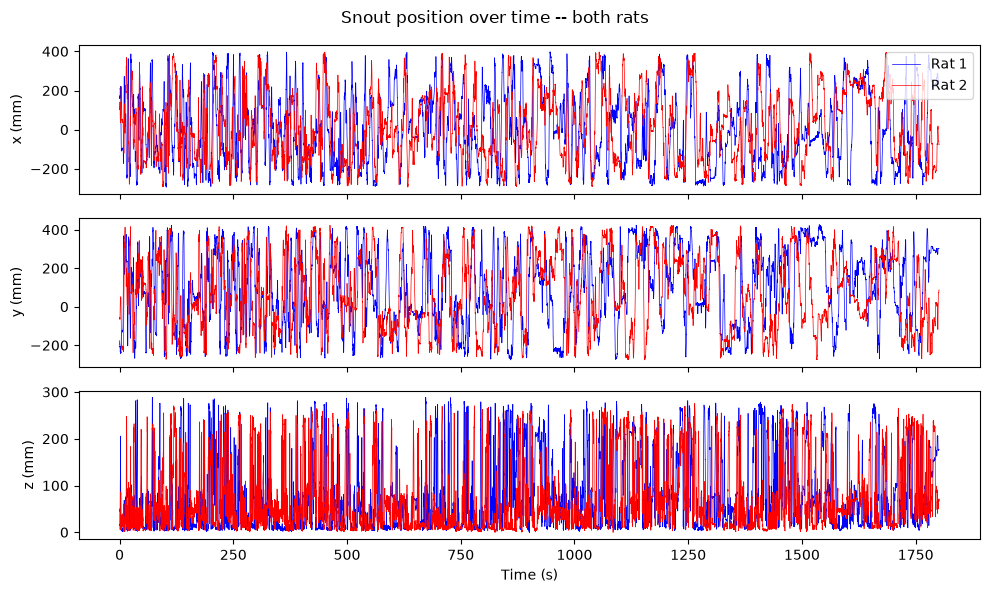

In [25]:
pair_pose = {rat_idx: ImportedMultiCameraPose & key for rat_idx, key in pair_keys.items()}
pair_df = {rat_idx: entry.fetch_pose_dataframe() for rat_idx, entry in pair_pose.items()}
assert np.array_equal(pair_df[1].index, pair_df[2].index), "the two rats are not on the same clock"

snout_xyz = {rat_idx: df[series_name("Snout")][["x", "y", "z"]].to_numpy() for rat_idx, df in pair_df.items()}
t = pair_df[1].index.to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, dim, label in zip(axes, range(3), ["x", "y", "z"]):
    for rat_idx in (1, 2):
        ax.plot(t, snout_xyz[rat_idx][:, dim], linewidth=0.5, color=RAT_COLORS[rat_idx], label=f"Rat {rat_idx}")
    ax.set_ylabel(f"{label} (mm)")
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Snout position over time -- both rats")
fig.tight_layout()

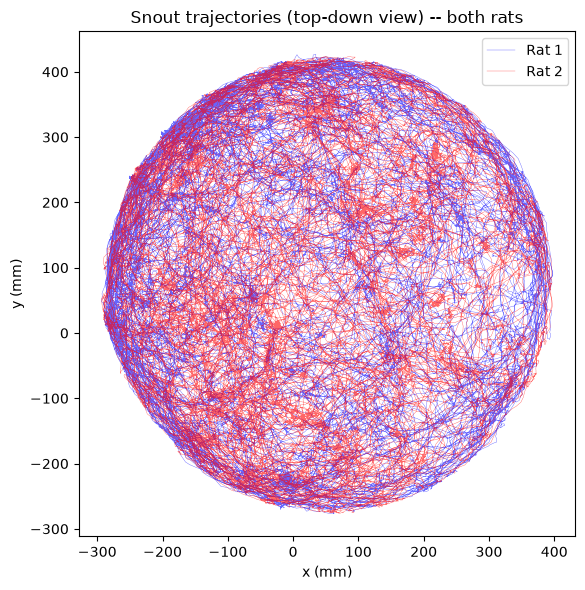

In [26]:
# Top-down (x, y) trajectories for both rats
fig, ax = plt.subplots(figsize=(6, 6))
for rat_idx in (1, 2):
    ax.plot(snout_xyz[rat_idx][:, 0], snout_xyz[rat_idx][:, 1], linewidth=0.3, alpha=0.6, color=RAT_COLORS[rat_idx], label=f"Rat {rat_idx}")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_aspect("equal")
ax.set_title("Snout trajectories (top-down view) -- both rats")
ax.legend()
fig.tight_layout()

## 3. Both rats' skeletons at a single frame

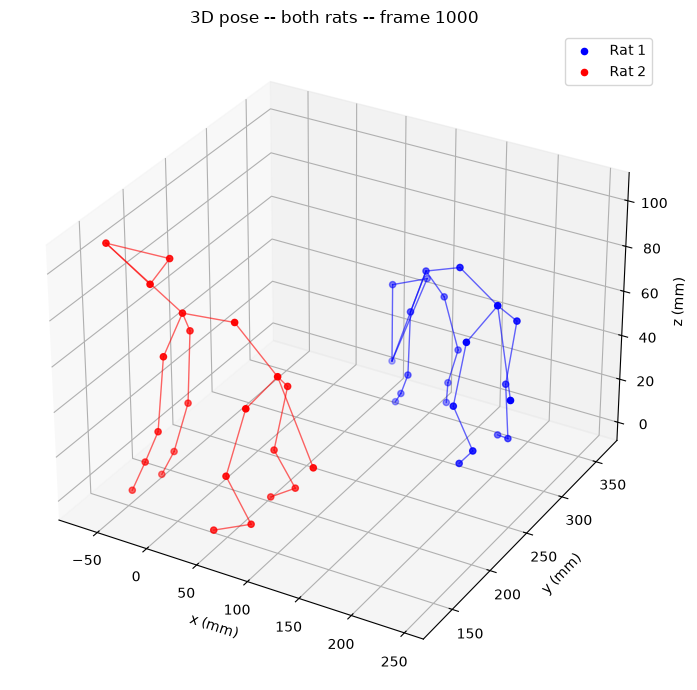

In [27]:
frame_idx = 1000

skeletons, coords = {}, {}
for rat_idx, entry in pair_pose.items():
    skeleton = entry.fetch_skeleton()
    nodes = skeleton["nodes"]
    skeletons[rat_idx] = {"nodes": nodes, "edges": [(nodes.index(a), nodes.index(b)) for a, b in skeleton["edges"]]}
    coords[rat_idx] = np.array(
        [pair_df[rat_idx][series_name(node)][["x", "y", "z"]].iloc[frame_idx].to_numpy() for node in nodes]
    )

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection="3d")
for rat_idx in (1, 2):
    xyz = coords[rat_idx]
    color = RAT_COLORS[rat_idx]
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=color, s=20, label=f"Rat {rat_idx}")
    for node_i, node_j in skeletons[rat_idx]["edges"]:
        xs, ys, zs = xyz[[node_i, node_j]].T
        ax.plot(xs, ys, zs, color=color, linewidth=1, alpha=0.6)

ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("z (mm)")
ax.set_title(f"3D pose -- both rats -- frame {frame_idx}")
ax.legend()
fig.tight_layout()

## 4. Both rats' poses overlaid on a video frame

The two rats' entries reference the same videos and the same camera calibrations, so one rat's
calibration projects either rat's keypoints.

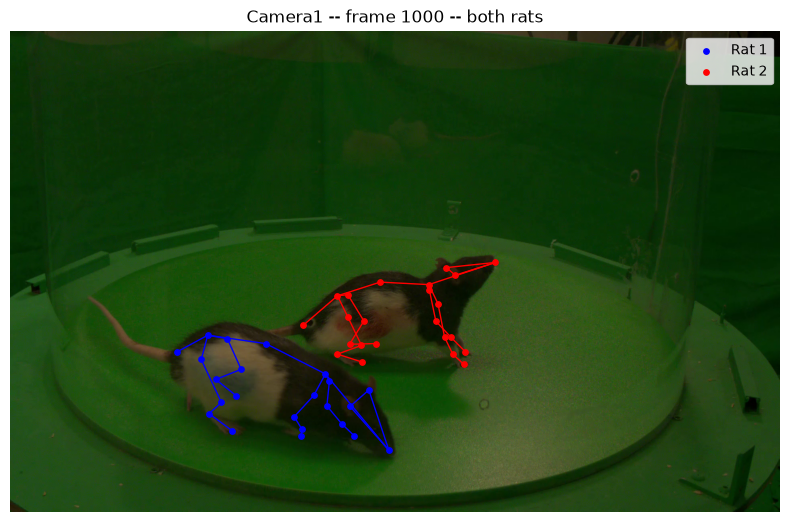

In [28]:
pair_calibrations = {rat_idx: entry.fetch_calibrations() for rat_idx, entry in pair_pose.items()}
pair_videos = {rat_idx: entry.fetch_video_paths() for rat_idx, entry in pair_pose.items()}
assert pair_videos[1] == pair_videos[2]
assert all(
    np.array_equal(pair_calibrations[1][camera][name], pair_calibrations[2][camera][name])
    for camera in pair_calibrations[1]
    for name in pair_calibrations[1][camera]
)

camera_to_display = "Camera1"
frame = read_frame(pair_videos[1][camera_to_display], frame_idx)  # frame_idx from section 3

if frame is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(frame)
    for rat_idx in (1, 2):
        points_2d = project_points(coords[rat_idx], pair_calibrations[1][camera_to_display])
        color = RAT_COLORS[rat_idx]
        for node_i, node_j in skeletons[rat_idx]["edges"]:
            xs, ys = points_2d[[node_i, node_j]].T
            ax.plot(xs, ys, color=color, linewidth=1)
        ax.scatter(points_2d[:, 0], points_2d[:, 1], color=color, s=15, zorder=3, label=f"Rat {rat_idx}")
    ax.set_title(f"{camera_to_display} -- frame {frame_idx} -- both rats")
    ax.legend()
    ax.axis("off")
    fig.tight_layout()
else:
    print(f"Could not read frame {frame_idx} from {camera_to_display}")

## 5. Body-contact events between the two rats

The contacts belong to the pair, so both rats' files hold the same table; read it from rat 1.

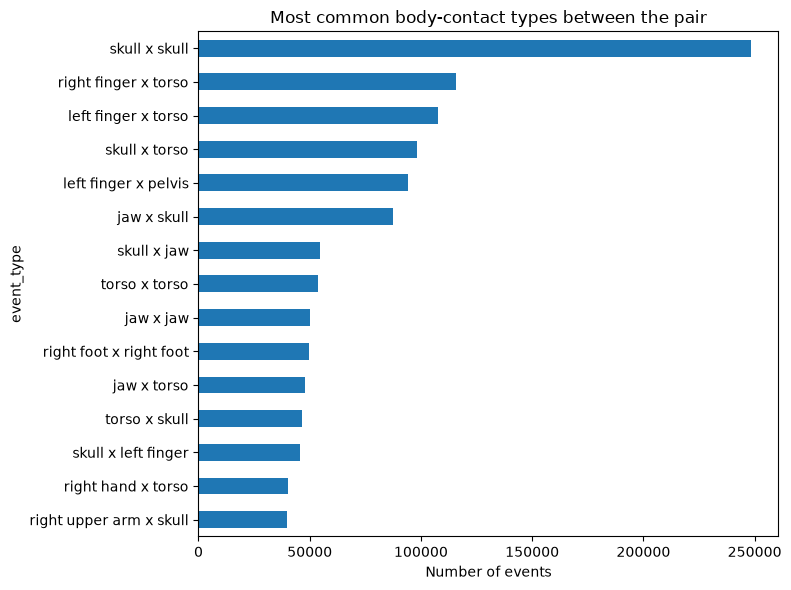

In [29]:
n_events = {rat_idx: (sgc.ImportedEvents & key).fetch1("n_events") for rat_idx, key in pair_keys.items()}
assert n_events[1] == n_events[2]

contacts_df = (sgc.ImportedEvents & pair_keys[1]).fetch1_dataframe()
top_contacts = contacts_df["event_type"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_contacts.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Number of events")
ax.set_title("Most common body-contact types between the pair")
fig.tight_layout()

## Summary

This notebook showed how to, from a Spyglass database:

- Check which sessions are ingested and that each is complete
- Inspect a session's subject, default epoch, cameras, calibrations and videos
- Fetch 3D pose (`fetch_pose_dataframe`) and the skeleton (`fetch_skeleton`), and plot
  trajectories and a full 3D pose
- Project 3D keypoints into a camera's pixels with its calibration (`fetch_calibrations`) and
  overlay them on the video frame (`fetch_video_paths`)
- Read the skin-contact events (`ImportedEvents.fetch1_dataframe`)
- Pair the two rats of a recording through their shared `session_id`

### Further resources

- [Spyglass documentation](https://lorenfranklab.github.io/spyglass/)
- [DANDI:001936](https://dandiarchive.org/dandiset/001936) and the NWB tutorials in
  `src/olveczky_lab_to_nwb/klibaite_2025_rat/notebooks/`
- [ndx-pose extension](https://github.com/rly/ndx-pose)